<a href="https://colab.research.google.com/github/mjcolebank/Colebank_REU_2026/blob/main/TEST_CNN_Example_Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Convolutional Neural Networks in PyTorch

This notebook walks through the application of **convolutional neural networks (CNNs)** using PyTorch.

We will study two examples:

1. A **2D CNN for image classification** on the MNIST handwritten digit dataset.
2. A **1D CNN for time-series classification** on a synthetic signal dataset.

The goal is to mirror the ideas from the NumPy implementation, but now using PyTorch's built-in tools:

- `torch.Tensor`
- `torch.nn.Module`
- `torch.nn.Conv2d`
- `torch.nn.Conv1d`
- `torch.nn.ReLU`
- `torch.nn.MaxPool2d`
- `torch.nn.Linear`
- `torch.optim`
- automatic differentiation through `loss.backward()`

PyTorch handles the tedious backpropagation bookkeeping for us, but the mathematical structure is the same as the NumPy version.



## 1. What is a Convolutional Neural Network?

A fully connected neural network treats each input feature as separate. For images, this ignores spatial structure. A CNN instead uses **filters**, also called **kernels**, that slide across an input and detect local patterns.

For a 2D image, a convolutional layer learns filters that may detect edges, corners, curves, or other local image features.

For a 1D time series, a convolutional layer learns filters that may detect spikes, oscillations, trends, or short temporal patterns.

A typical CNN layer sequence is:

\[
\text{Input} \rightarrow \text{Convolution} \rightarrow \text{Activation} \rightarrow \text{Pooling} \rightarrow \text{Dense Layers} \rightarrow \text{Prediction}.
\]

In PyTorch, these operations are represented as neural network layers.



## 2. Imports and Reproducibility

We will use PyTorch for neural network layers and training, NumPy for data generation, and Matplotlib for visualization.


In [ ]:

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split

# Optional imports for MNIST.
# If torchvision is not installed, the synthetic time-series example will still run.
try:
    import torchvision
    import torchvision.transforms as transforms
    TORCHVISION_AVAILABLE = True
except ImportError:
    TORCHVISION_AVAILABLE = False

np.random.seed(42)
torch.manual_seed(42)

# Use a GPU if available. Otherwise, use CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu



## 3. Helper Function: Training Loop

The same basic PyTorch training loop will be used for both the image example and the time-series example.

For each epoch:

1. Load a mini-batch.
2. Compute predictions.
3. Compute the loss.
4. Clear previous gradients.
5. Backpropagate using `loss.backward()`.
6. Update parameters using the optimizer.

For classification, we will use `nn.CrossEntropyLoss()`. This loss combines:

- a softmax operation, and
- the negative log-likelihood loss.

Therefore, our models should output raw scores, also called **logits**, not softmax probabilities.


In [ ]:

def train_classifier(model, train_loader, test_loader=None, epochs=5, learning_rate=1e-3, verbose=True):
    # Train a PyTorch classifier using cross-entropy loss.
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        correct = 0
        total = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batch_size = X_batch.shape[0]
            total_loss += loss.item() * batch_size
            predictions = torch.argmax(logits, dim=1)
            correct += (predictions == y_batch).sum().item()
            total += batch_size

        train_loss = total_loss / total
        train_acc = correct / total
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        if test_loader is not None:
            test_loss, test_acc = evaluate_classifier(model, test_loader, criterion)
            history["test_loss"].append(test_loss)
            history["test_acc"].append(test_acc)

            if verbose:
                print(
                    f"Epoch {epoch + 1}/{epochs}: "
                    f"train loss = {train_loss:.4f}, train acc = {train_acc:.4f}, "
                    f"test loss = {test_loss:.4f}, test acc = {test_acc:.4f}"
                )
        else:
            if verbose:
                print(
                    f"Epoch {epoch + 1}/{epochs}: "
                    f"train loss = {train_loss:.4f}, train acc = {train_acc:.4f}"
                )

    return history


def evaluate_classifier(model, data_loader, criterion=None):
    # Evaluate classification loss and accuracy.
    model.eval()

    if criterion is None:
        criterion = nn.CrossEntropyLoss()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            batch_size = X_batch.shape[0]
            total_loss += loss.item() * batch_size
            predictions = torch.argmax(logits, dim=1)
            correct += (predictions == y_batch).sum().item()
            total += batch_size

    return total_loss / total, correct / total



## 4. Helper Function: Plot Training Curves


In [ ]:

def plot_history(history, title="Training History"):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_loss"], label="train loss")
    if len(history["test_loss"]) > 0:
        plt.plot(epochs, history["test_loss"], label="test loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + ": Loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_acc"], label="train accuracy")
    if len(history["test_acc"]) > 0:
        plt.plot(epochs, history["test_acc"], label="test accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title + ": Accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()



# Part I: A 2D CNN for MNIST

MNIST is a standard image classification dataset containing grayscale images of handwritten digits.

Each image has shape:

\[
28 \times 28.
\]

In PyTorch, a batch of grayscale MNIST images has shape:

\[
N \times C \times H \times W,
\]

where:

- `N` is the batch size,
- `C = 1` is the number of channels,
- `H = 28` is the image height,
- `W = 28` is the image width.

The output has 10 classes, corresponding to digits 0 through 9.



## 5. Load MNIST

This cell downloads MNIST using `torchvision.datasets.MNIST`.

If you are running this notebook somewhere without internet access or without `torchvision`, skip the MNIST training section and run the 1D time-series example instead.


In [ ]:

if TORCHVISION_AVAILABLE:
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    mnist_train_full = torchvision.datasets.MNIST(
        root="./data",
        train=True,
        download=True,
        transform=transform
    )

    mnist_test = torchvision.datasets.MNIST(
        root="./data",
        train=False,
        download=True,
        transform=transform
    )

    # Use a smaller subset to keep this notebook fast for classroom demonstration.
    train_subset_size = 10000
    val_subset_size = len(mnist_train_full) - train_subset_size
    mnist_train, _ = random_split(
        mnist_train_full,
        [train_subset_size, val_subset_size],
        generator=torch.Generator().manual_seed(42)
    )

    test_subset_size = 2000
    _, mnist_test_small = random_split(
        mnist_test,
        [len(mnist_test) - test_subset_size, test_subset_size],
        generator=torch.Generator().manual_seed(42)
    )

    mnist_train_loader = DataLoader(mnist_train, batch_size=64, shuffle=True)
    mnist_test_loader = DataLoader(mnist_test_small, batch_size=256, shuffle=False)

    print("MNIST train subset size:", len(mnist_train))
    print("MNIST test subset size:", len(mnist_test_small))
else:
    print("torchvision is not available. Skip the MNIST cells and run the 1D time-series example.")


Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 23.8MB/s]


Extracting ./data\MNIST\raw\train-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 2.33MB/s]


Extracting ./data\MNIST\raw\train-labels-idx1-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 10.8MB/s]


Extracting ./data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]


Extracting ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\MNIST\raw

MNIST train subset size: 10000
MNIST test subset size: 2000



## 6. Visualize MNIST Images


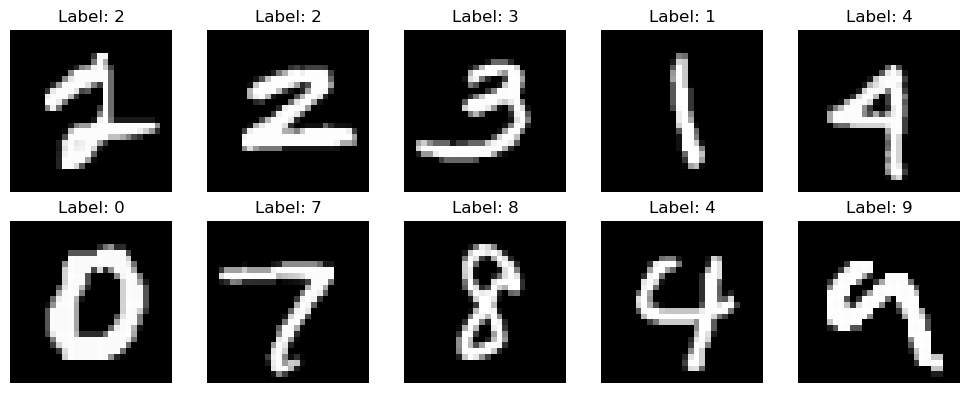

In [ ]:

if TORCHVISION_AVAILABLE:
    images, labels = next(iter(mnist_train_loader))

    plt.figure(figsize=(10, 4))
    for i in range(10):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[i, 0], cmap="gray")
        plt.title(f"Label: {labels[i].item()}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()



## 7. Define a 2D CNN for MNIST

The model below uses:

1. `nn.Conv2d(1, 8, kernel_size=3, padding=1)`
2. `nn.ReLU()`
3. `nn.MaxPool2d(2)`
4. `nn.Conv2d(8, 16, kernel_size=3, padding=1)`
5. `nn.ReLU()`
6. `nn.MaxPool2d(2)`
7. A fully connected classifier

The input image begins as `1 x 28 x 28`.

After the first pooling layer, the spatial size becomes `14 x 14`.

After the second pooling layer, the spatial size becomes `7 x 7`.

The final convolutional feature tensor has shape:

\[
16 \times 7 \times 7.
\]

This is flattened and passed to dense layers.


In [ ]:

class MNISTConvNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 7 * 7, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


mnist_model = MNISTConvNet()
print(mnist_model)


MNISTConvNet(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=10, bias=True)
  )
)



## 8. Train the MNIST CNN

This pure PyTorch version should train much faster than the NumPy version because PyTorch uses optimized tensor operations and automatic differentiation.

You can increase `epochs` for better performance.


Epoch 1/5: train loss = 0.6726, train acc = 0.8073, test loss = 0.2524, test acc = 0.9290
Epoch 2/5: train loss = 0.1993, train acc = 0.9413, test loss = 0.1784, test acc = 0.9425
Epoch 3/5: train loss = 0.1412, train acc = 0.9556, test loss = 0.1174, test acc = 0.9585
Epoch 4/5: train loss = 0.0964, train acc = 0.9715, test loss = 0.0997, test acc = 0.9630
Epoch 5/5: train loss = 0.0779, train acc = 0.9747, test loss = 0.0790, test acc = 0.9700


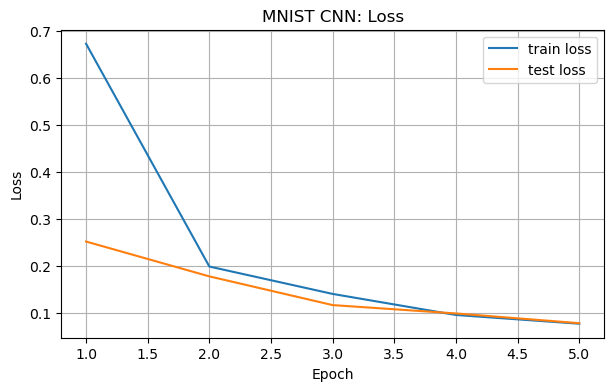

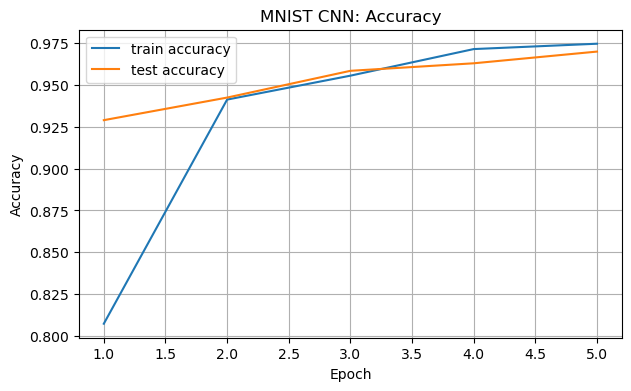

In [ ]:

if TORCHVISION_AVAILABLE:
    mnist_history = train_classifier(
        mnist_model,
        mnist_train_loader,
        mnist_test_loader,
        epochs=5,
        learning_rate=1e-3,
        verbose=True
    )

    plot_history(mnist_history, title="MNIST CNN")



## 9. Inspect MNIST Predictions


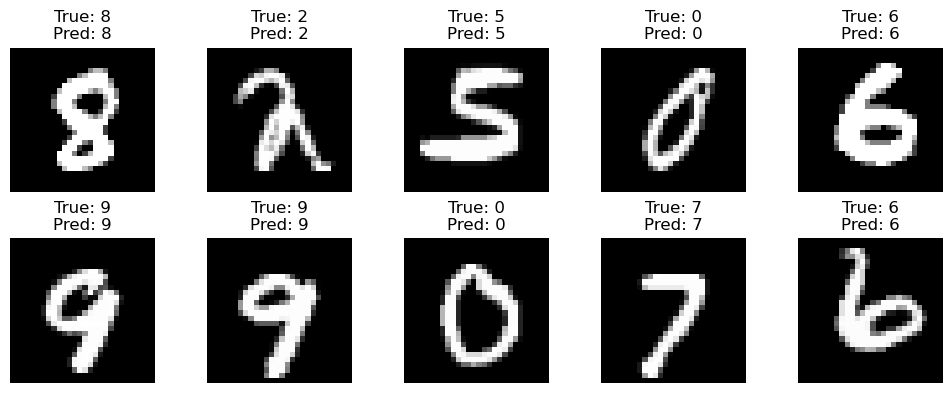

In [ ]:

if TORCHVISION_AVAILABLE:
    mnist_model.eval()

    images, labels = next(iter(mnist_test_loader))
    images_device = images.to(device)

    with torch.no_grad():
        logits = mnist_model(images_device)
        preds = torch.argmax(logits, dim=1).cpu()

    plt.figure(figsize=(10, 4))
    for i in range(10):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[i, 0], cmap="gray")
        plt.title(f"True: {labels[i].item()}\nPred: {preds[i].item()}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()



# Part II: A 1D CNN for Time-Series Classification

CNNs are not only for images. A 1D CNN can be applied to sequential data such as:

- sensor measurements,
- financial signals,
- ECG or EEG recordings,
- audio waveforms,
- machine monitoring data,
- traffic or demand data.

A 1D convolutional layer slides filters along the time axis.

For PyTorch `nn.Conv1d`, the input shape is:

\[
N \times C \times L,
\]

where:

- `N` is the batch size,
- `C` is the number of input channels,
- `L` is the sequence length.

For a single univariate time series, `C = 1`.



## 10. Generate a Synthetic Time-Series Dataset

We will create a three-class time-series classification problem.

Each signal has length 100.

The classes are:

- Class 0: low-frequency sine wave,
- Class 1: high-frequency sine wave,
- Class 2: square-wave-like signal.

Noise is added so the classification task is not completely trivial.


In [ ]:

def make_time_series_dataset(n_per_class=300, length=100, noise_std=0.25, seed=42):
    rng = np.random.default_rng(seed)
    t = np.linspace(0, 1, length)

    X_list = []
    y_list = []

    for class_label in range(3):
        for _ in range(n_per_class):
            phase = rng.uniform(0, 2 * np.pi)
            amplitude = rng.uniform(0.8, 1.2)
            noise = noise_std * rng.normal(size=length)

            if class_label == 0:
                signal = amplitude * np.sin(2 * np.pi * 3 * t + phase)
            elif class_label == 1:
                signal = amplitude * np.sin(2 * np.pi * 9 * t + phase)
            else:
                signal = amplitude * np.sign(np.sin(2 * np.pi * 5 * t + phase))

            signal = signal + noise
            X_list.append(signal)
            y_list.append(class_label)

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.int64)

    # PyTorch Conv1d expects shape [N, C, L].
    X = X[:, None, :]

    # Shuffle data.
    perm = rng.permutation(len(y))
    X = X[perm]
    y = y[perm]

    return X, y, t


X_ts, y_ts, t = make_time_series_dataset(n_per_class=300, length=100)
print("X_ts shape:", X_ts.shape)
print("y_ts shape:", y_ts.shape)


X_ts shape: (900, 1, 100)
y_ts shape: (900,)



## 11. Visualize Example Time Series


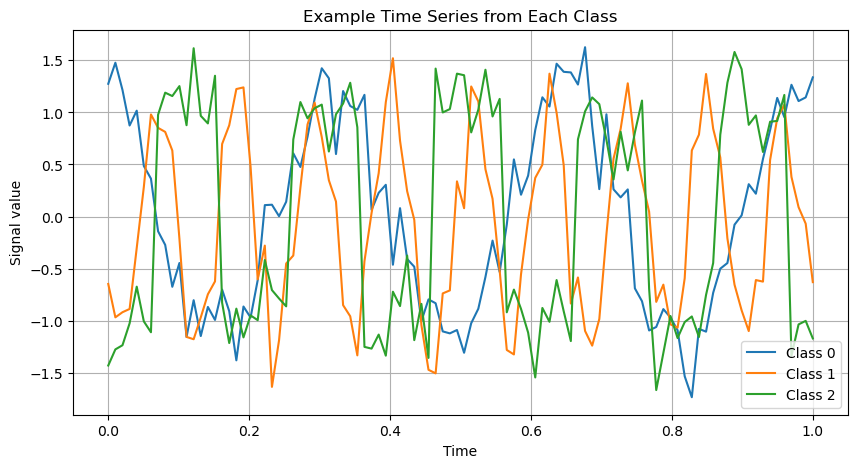

In [ ]:

plt.figure(figsize=(10, 5))
for class_label in range(3):
    idx = np.where(y_ts == class_label)[0][0]
    plt.plot(t, X_ts[idx, 0], label=f"Class {class_label}")

plt.xlabel("Time")
plt.ylabel("Signal value")
plt.title("Example Time Series from Each Class")
plt.grid(True)
plt.legend()
plt.show()



## 12. Create PyTorch DataLoaders for Time Series


In [ ]:

X_ts_tensor = torch.tensor(X_ts, dtype=torch.float32)
y_ts_tensor = torch.tensor(y_ts, dtype=torch.long)

ts_dataset = TensorDataset(X_ts_tensor, y_ts_tensor)

train_size = int(0.8 * len(ts_dataset))
test_size = len(ts_dataset) - train_size

ts_train_dataset, ts_test_dataset = random_split(
    ts_dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

ts_train_loader = DataLoader(ts_train_dataset, batch_size=32, shuffle=True)
ts_test_loader = DataLoader(ts_test_dataset, batch_size=128, shuffle=False)

print("Time-series training samples:", len(ts_train_dataset))
print("Time-series test samples:", len(ts_test_dataset))


Time-series training samples: 720
Time-series test samples: 180



## 13. Define a 1D CNN for Time-Series Classification

This model uses:

1. `nn.Conv1d(1, 8, kernel_size=5, padding=2)`
2. `nn.ReLU()`
3. `nn.MaxPool1d(2)`
4. `nn.Conv1d(8, 16, kernel_size=5, padding=2)`
5. `nn.ReLU()`
6. `nn.MaxPool1d(2)`
7. Dense classifier layers

The original sequence length is 100.

After the first max pooling layer, the length becomes 50.

After the second max pooling layer, the length becomes 25.

The final convolutional feature tensor has shape:

\[
16 \times 25.
\]


In [ ]:

class TimeSeriesConvNet(nn.Module):
    def __init__(self, sequence_length=100, num_classes=3, kernel_size=5):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=8, kernel_size=6, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(in_channels=8, out_channels=16, kernel_size=6, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )

        reduced_length = sequence_length // 4

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * reduced_length, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


ts_model = TimeSeriesConvNet(sequence_length=100, num_classes=3)
print(ts_model)


TimeSeriesConvNet(
  (features): Sequential(
    (0): Conv1d(1, 8, kernel_size=(6,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(8, 16, kernel_size=(6,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=400, out_features=32, bias=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=3, bias=True)
  )
)



## 14. Train the 1D CNN


In [ ]:

ts_history = train_classifier(
    ts_model,
    ts_train_loader,
    ts_test_loader,
    epochs=15,
    learning_rate=1e-3,
    verbose=True
)

plot_history(ts_history, title="1D CNN Time-Series Classifier")


RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x384 and 400x32)


## 15. Inspect Time-Series Predictions


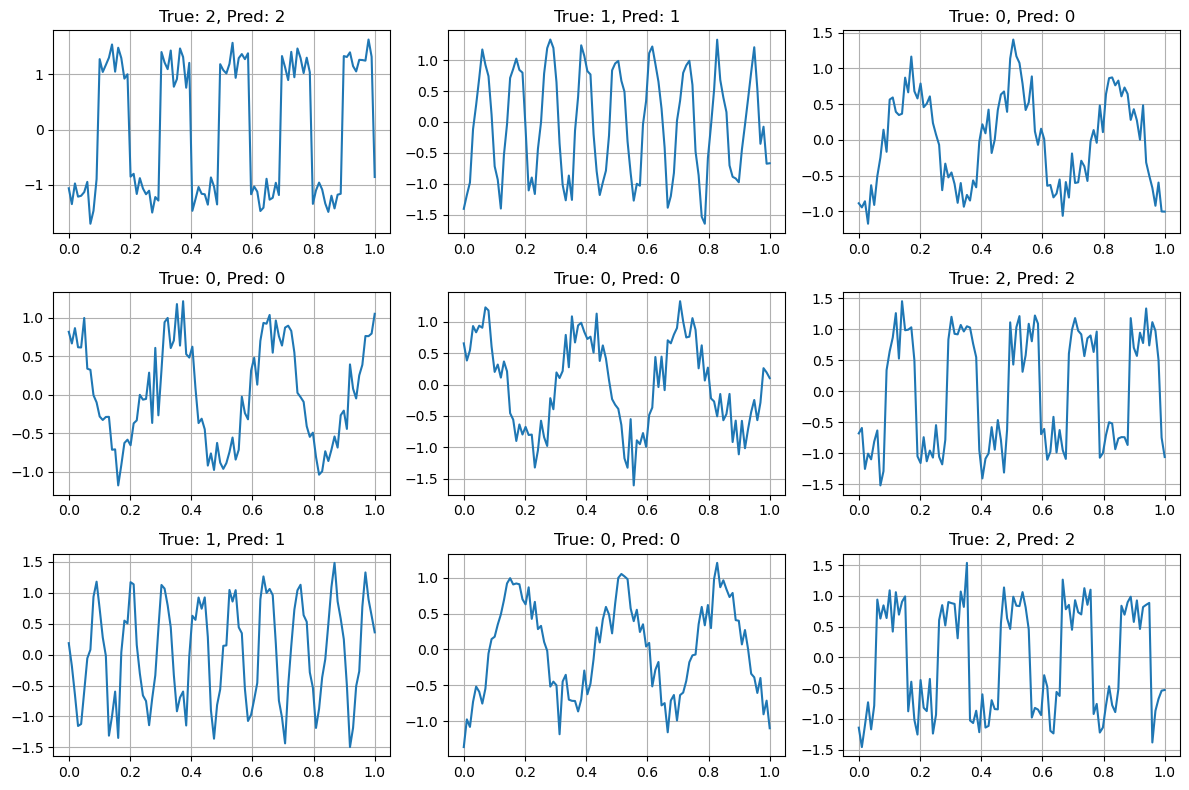

In [ ]:

ts_model.eval()

X_batch, y_batch = next(iter(ts_test_loader))

with torch.no_grad():
    logits = ts_model(X_batch.to(device))
    predictions = torch.argmax(logits, dim=1).cpu()

plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.plot(t, X_batch[i, 0].numpy())
    plt.title(f"True: {y_batch[i].item()}, Pred: {predictions[i].item()}")
    plt.grid(True)

plt.tight_layout()
plt.show()



## 16. Optional: Visualize Learned 1D Filters

The first convolutional layer learns small time-domain filters. Each filter has length 5 in this example.

These learned filters can be thought of as small pattern detectors.


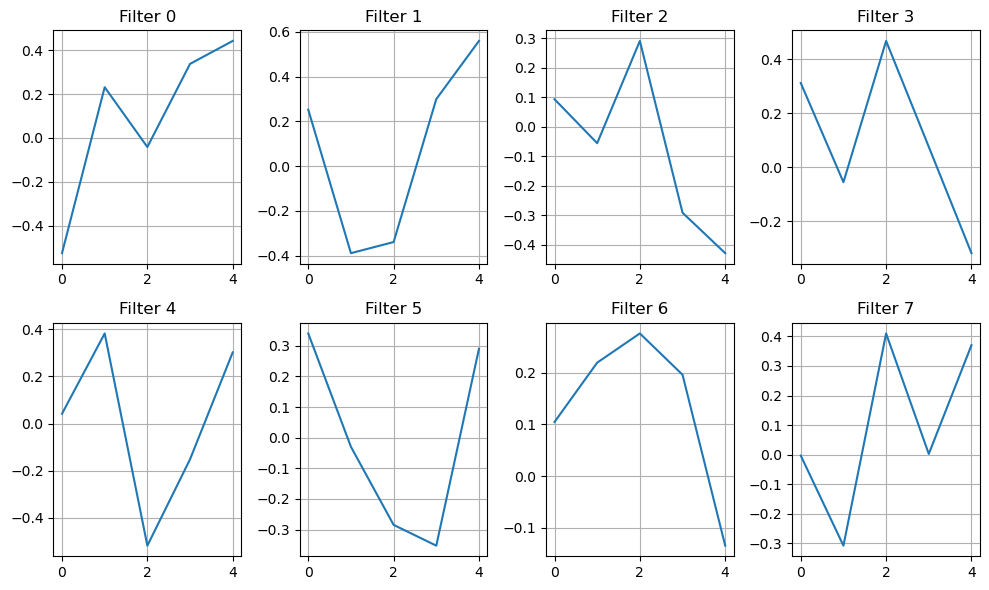

In [ ]:

first_conv = ts_model.features[0]
filters = first_conv.weight.detach().cpu().numpy()

plt.figure(figsize=(10, 6))
for i in range(filters.shape[0]):
    plt.subplot(2, 4, i + 1)
    plt.plot(filters[i, 0])
    plt.title(f"Filter {i}")
    plt.grid(True)

plt.tight_layout()
plt.show()



# Summary

This notebook showed two applications of convolutional neural networks in PyTorch.

## 2D CNN for MNIST

A 2D CNN uses filters that slide across image height and width. This is useful for image data because nearby pixels contain meaningful local structure.

## 1D CNN for Time Series

A 1D CNN uses filters that slide along the time axis. This is useful for detecting short temporal patterns such as oscillations, spikes, jumps, or repeated motifs.

## Key PyTorch Ideas

The most important PyTorch components were:

- `nn.Conv2d` for image convolution,
- `nn.Conv1d` for time-series convolution,
- `nn.ReLU` for nonlinear activation,
- `nn.MaxPool2d` and `nn.MaxPool1d` for downsampling,
- `nn.Linear` for dense classification layers,
- `nn.CrossEntropyLoss` for multiclass classification,
- `loss.backward()` for automatic backpropagation,
- `torch.optim.Adam` for parameter updates.

Compared with the NumPy implementation, PyTorch makes the neural network code much shorter because it handles gradients automatically.
